# Daily Occupancy Forecasting & Demand Dynamics Modeling
#### Notebook 2: Feature Engineering, Forecasting, and Guardrail / Directional Analysis

This notebook builds on the cleaned daily dataset produced in Notebook 1.

The goal here is not only to forecast future occupancy, but to do so in a way that reflects the operational logic of the business. In particular, occupancy is treated as a dynamic system influenced by:

- persistence in the current occupancy state
- seasonal structure
- booking inflows
- notice outflows
- timing-adjusted demand pressure
- short-term instability conditions

The notebook therefore develops three complementary layers:

1. **Point forecasting**, to estimate future occupancy at multiple horizons  
2. **Guardrail analysis**, to identify periods where prediction risk is structurally higher  
3. **Directional / operational modeling**, to translate forecasts into practical business actions

This structure reflects the idea that a useful forecasting system should not only predict levels, but also communicate uncertainty and support decisions.


##### ***Why linear models were used***

Linear models were chosen as the main starting point for three reasons.

First, this project is not only predictive but also explanatory. The goal is to understand how occupancy changes in relation to persistence, seasonality, bookings, notices, and flow pressure. Linear regression makes those relationships interpretable.

Second, the dataset is relatively small for a daily forecasting task, with roughly four years of observations. In that setting, simpler models provide a strong baseline and reduce the risk of overfitting.

Third, the business logic is close to an additive state-transition process, where future occupancy evolves from current state plus inflow and outflow effects. Linear models are therefore a natural first benchmark before testing more complex algorithms.

### 1. Imports and Load

This notebook starts from the cleaned daily dataset built in Notebook 1.
At this stage, the original weekly tracking data has already been converted into a daily operational time series suitable for forecasting.

In [72]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    classification_report,
    confusion_matrix
)

# Load the cleaned daily dataset built in Notebook 1
daily = pd.read_csv("daily_cleaned_dataset.csv", parse_dates=["Date"])

print(daily.shape)
daily.head()

(1247, 12)


,Date,Occupied_Units,Week,Occupancy,Bookings,Notices,Avg_Booking_Time,Avg_Notice_Time,Has_Bookings,Has_Notices,units_available,Missing_Occupancy_Flag
0,2016-08-01,60.0,2016-W31,0.857143,6.0,1.0,7.500000,18.000000,1,1,70.0,0
1,2016-08-02,59.0,2016-W31,0.842857,0.0,0.0,8.333333,14.000000,0,0,70.0,0
2,2016-08-03,58.0,2016-W31,0.828571,3.0,3.0,9.333333,5.666667,1,1,70.0,0
3,2016-08-04,59.0,2016-W31,0.842857,0.0,0.0,8.333333,14.000000,0,0,70.0,0
4,2016-08-05,56.0,2016-W31,0.800000,0.0,1.0,8.333333,4.000000,0,1,70.0,0


### 2. Import reusable project functions

#### 2.1 Features

The feature design follows the operational logic introduced in Notebook 1.

Instead of relying only on generic time-series lags, the model combines three types of information:

- **state persistence**, through lagged occupancy
- **seasonal recurrence**, through calendar and seasonal averages
- **demand dynamics**, through bookings, notices, and timing-adjusted pressure variables

This is a key modeling choice. The business does not evolve through purely random daily variation; it evolves through a combination of current occupancy, inflows, outflows, and recurrent periods. The features are therefore meant to capture both the statistical structure and the real operational mechanism behind occupancy changes.

In [73]:
from forecast_utils import (
    add_features,
    compute_spike_threshold,
    apply_spike_labels
)

#### 2.2 Train/test split and forecasting models

The forecasting setup is intentionally conservative and interpretable.

Three design choices are especially important:

1. **Chronological split**  
   The train/test split preserves the time structure of the problem, which is essential in forecasting.

2. **Train-only seasonal baseline**  
   Seasonal averages are estimated only from the training data to avoid information leakage.

3. **Naive benchmark by horizon**  
   Each model is compared against a realistic baseline for that horizon. This provides a stronger test of value than simply reporting error metrics.

This section therefore frames the forecasting task as a practical comparison: does the model provide useful information beyond persistence and seasonality?

In [74]:
from forecast_utils import (
    split_train_test_pre_2019_with_seasonality,
    run_linear_model,
    build_guardrail
)

#### 2.3 Guardrail and Spikes Analysis

A forecasting model can perform reasonably well on average while still failing during the periods that matter most operationally.  
In this business, those periods are often the days with unusually strong booking or notice pressure.

For that reason, two additional layers are introduced:

- **spike analysis**, to understand whether large occupancy changes occur in identifiable temporal patterns
- **guardrail analysis**, to mark periods where the system is under stress and forecast reliability may fall

This reflects a practical forecasting view: average accuracy matters, but decision quality during unstable periods matters even more.

In [75]:
from forecast_utils import (
    evaluate_with_guardrail,
    analyze_spikes
)

#### 2.4 Ridge Model Extension

Ridge is included as a robustness check

In [76]:
from forecast_utils import (
    run_ridge_model
)

#### 2.5 Directional and Operational Layer

Point forecasts are useful, but many business decisions are not based on the exact future occupancy value alone.  
They are often based on whether demand is likely to move **up**, **down**, or remain too uncertain to justify action.

The directional layer therefore reframes the task in operational terms:

- Is a meaningful increase likely?
- Is a meaningful decrease likely?
- Or is the signal too weak to trust?

This allows the forecasting system to become more decision-oriented, especially when paired with a confidence threshold and the guardrail logic.

In [77]:
from forecast_utils import (
    add_direction_target,
    run_direction_model,
    add_selective_direction_output,
    evaluate_selective_direction,
    run_direction_workflow,
    build_operational_signal_multi
)

### 3. Feature engineering, train/test split, and spike labeling

At this point, the modeling dataset is fully prepared.

This step is where the project moves from data preparation into modeling design.  
Three layers are now defined simultaneously:

- the **forecasting targets** for multiple horizons
- the **directional targets** for operational classification
- the **spike labels** used to analyze large changes and instability

Using a train-only spike threshold is especially important, because it keeps the evaluation realistic and avoids learning the definition of a spike from future data.

In [78]:
# Build the full engineered feature set.
daily = add_features(daily)

# Remove rows with missing values caused by lag creation and future targets.
# This produces the final modeling dataset.
daily_model = daily.dropna().copy()

# Naive delta baseline: predict no change.
# This is the natural baseline when modeling occupancy change directly.
daily_model["naive_delta"] = 0.0

# Chronological split + train-based seasonal normalization.
train, test = split_train_test_pre_2019_with_seasonality(daily_model)

# Create directional labels for all horizons.
# This supports later classification-based directional analysis.
horizons = ["t1", "t7", "t14", "t21", "t28"]

for h in horizons:
    train = add_direction_target(
        train,
        target_col=f"target_{h}",
        new_col=f"Direction_{h}",
        threshold=0.005
    )
    test = add_direction_target(
        test,
        target_col=f"target_{h}",
        new_col=f"Direction_{h}",
        threshold=0.005
    )

# Estimate spike threshold on training data only.
spike_threshold = compute_spike_threshold(train, quantile=0.80)

# Apply the same threshold to both train and test.
train = apply_spike_labels(train, spike_threshold)
test = apply_spike_labels(test, spike_threshold)

print("Spike threshold:", round(spike_threshold, 6))
print("Train spikes:", train["Spike"].sum(), "| Test spikes:", test["Spike"].sum())
print("Train shape:", train.shape, "| Test shape:", test.shape)

Spike threshold: 0.027778
Train spikes: 168 | Test spikes: 41
Train shape: (855, 60) | Test shape: (336, 60)


### 4. Spike exploration

The spike analysis is meant to answer a structural question:  
are large occupancy changes simply irregular shocks, or do they recur in identifiable periods?

If spikes cluster by month or by week-of-year, that suggests they are at least partly systematic and may be linked to:

- seasonal transitions
- holiday periods
- recurring booking or notice behavior
- business-specific operating cycles

If instead they are scattered with no clear pattern, then spike prediction becomes inherently harder and may require richer external or customer-level signals.

In [79]:
# Explore whether spikes appear randomly or cluster in specific recurring periods.
# This helps determine whether extreme changes may partly reflect seasonality
# or calendar structure rather than pure noise.
spikes, spike_pivot = analyze_spikes(pd.concat([train, test]))


Spikes by month
Month
1     20
2     14
3      8
4     15
5     25
6     15
7     18
8     23
9     26
10    13
11     8
12    24
Name: count, dtype: int64

Spikes by week and year
Year        2016  2017  2018  2019
WeekOfYear                        
1            0.0   4.0   2.0   0.0
2            0.0   5.0   2.0   2.0
3            0.0   2.0   2.0   0.0
4            0.0   1.0   0.0   0.0
5            0.0   2.0   0.0   2.0
6            0.0   1.0   1.0   0.0
7            0.0   2.0   1.0   1.0
8            0.0   2.0   0.0   1.0
9            0.0   1.0   1.0   0.0
10           0.0   1.0   0.0   1.0
12           0.0   0.0   1.0   1.0
13           0.0   1.0   1.0   1.0
14           0.0   2.0   2.0   1.0
15           0.0   3.0   0.0   0.0
16           0.0   3.0   0.0   0.0
17           0.0   1.0   1.0   1.0
18           0.0   5.0   1.0   2.0
19           0.0   3.0   0.0   1.0
20           0.0   2.0   1.0   2.0
21           0.0   3.0   2.0   1.0
22           0.0   1.0   1.0   4.0
23           

### 5. Feature sets by forecasting horizon

The horizon-specific feature design reflects a key modeling assumption:

- **very short-term forecasts** are mainly driven by persistence
- **medium-term forecasts** have more time to absorb the effect of bookings, notices, and pressure variables

This matters because the same feature set is not equally informative at all horizons.  
A useful forecasting system should therefore allow the data-generating logic to change with forecast distance.

In [80]:
# T+1 forecasting is expected to be dominated by persistence.
# Short-term occupancy usually changes smoothly, so recent occupancy levels
# and short-run momentum matter most.
features_t1 = [
    "Seasonal_Avg",
    "Occ_vs_Seasonal",
    "Lag_1d",
    "Lag_2d",
    "Lag_7d",
    "Delta_1d",
    "Acceleration",
    "dow_sin",
    "dow_cos",
    "doy_sin",
    "doy_cos",
    "Is_Christmas_Period"
]

# Medium horizons can benefit more from flow variables,
# because bookings and notices need time to propagate into occupancy.
features_medium = [
    "Seasonal_Avg",
    "Occ_vs_Seasonal",
    "Lag_7d",
    "Lag_14d",
    "Net_Flow",
    "Demand_Pressure",
    "Booking_Intensity",
    "Notice_Pressure",
    "Eff_Net_Flow",
    "Eff_Net_Flow_Lag_7",
    "Has_Bookings",
    "Has_Notices",
    "doy_sin",
    "doy_cos",
    "Is_Christmas_Period",
    "Is_Summer_Period"
]

# Directional models reuse horizon-aligned features for consistency.
direction_feature_map = {
    "T+1": features_t1,
    "T+7": features_medium,
    "T+14": features_medium,
    "T+21": features_medium,
    "T+28": features_medium
}

### 6. Forecasting models across horizons

In [81]:
# Fit interpretable linear models across all forecast horizons.
# Each horizon is compared with its correct naive baseline.
model_configs = {
    "T+1": ("target_t1", "Occupancy", features_t1),
    "T+7": ("target_t7", "Lag_7d", features_medium),
    "T+14": ("target_t14", "Lag_14d", features_medium),
    "T+21": ("target_t21", "Lag_21d", features_medium),
    "T+28": ("target_t28", "Lag_28d", features_medium),
}

results = {}

for label, (target, naive, feats) in model_configs.items():
    results[label] = run_linear_model(
        train=train,
        test=test,
        features=feats,
        target_col=target,
        naive_col=naive,
        label=label
    )


=== T+1 MODEL ===
MAE: 0.01325
RMSE: 0.01821

=== T+1 NAIVE ===
MAE: 0.0121
RMSE: 0.01814

=== IMPROVEMENT T+1 ===
MAE improvement: -0.00115

=== T+1 COEFFICIENTS ===
Occ_vs_Seasonal        1.040869
Seasonal_Avg           1.013262
Lag_1d                -0.041746
Delta_1d              -0.033716
Is_Christmas_Period   -0.027124
Lag_7d                -0.025871
Acceleration           0.020411
Lag_2d                -0.008030
doy_sin               -0.001318
dow_sin               -0.001082
doy_cos                0.000594
dow_cos               -0.000281
dtype: float64

=== T+7 MODEL ===
MAE: 0.04245
RMSE: 0.05288

=== T+7 NAIVE ===
MAE: 0.05397
RMSE: 0.06856

=== IMPROVEMENT T+7 ===
MAE improvement: 0.01152

=== T+7 COEFFICIENTS ===
Occ_vs_Seasonal        1.022062
Seasonal_Avg           0.704836
Lag_7d                -0.277487
Booking_Intensity     -0.272413
Demand_Pressure       -0.222629
Is_Christmas_Period   -0.177562
Lag_14d                0.066931
Notice_Pressure       -0.049784
Eff_Net_F

At **T+1**, the model performs worse than the naive baseline.

This confirms that next-day occupancy is **strongly driven by persistence**.

The most important signals are the current occupancy level and its position relative to seasonality. Flow variables such as bookings and notices do **not have an immediate effect**, so they do not improve short-term forecasts.

### 7. Forecast summary

In [82]:
# Consolidate forecasting performance across horizons.
# This allows the trade-off between horizon length and predictive accuracy
# to be compared directly.
ordered_horizons = ["T+1", "T+7", "T+14", "T+21", "T+28"]

summary = pd.DataFrame([
    {
        "Horizon": horizon,
        "Model_MAE": results[horizon]["mae_model"],
        "Naive_MAE": results[horizon]["mae_naive"],
        "MAE_Improvement": results[horizon]["mae_naive"] - results[horizon]["mae_model"]
    }
    for horizon in ordered_horizons
])

print(summary)

  Horizon  Model_MAE  Naive_MAE  MAE_Improvement
0     T+1   0.013246   0.012100        -0.001146
1     T+7   0.042448   0.053968         0.011520
2    T+14   0.056774   0.082718         0.025944
3    T+21   0.067360   0.106790         0.039429
4    T+28   0.071941   0.113366         0.041425


The model does not beat the naive baseline at T+1, but improves clearly **T+7 onward**.
This suggests that **bookings, notices, and seasonality need time to impact occupancy**, and are more useful at longer horizons.

### 8. Guardrail (instability) 

The purpose of the guardrail is not to improve forecasts directly, but to improve how forecasts are used.

If error is consistently higher when the guardrail is ON, then the guardrail is doing something useful:  
it is identifying periods where the system is structurally less predictable.

That would support an operational conclusion such as:

- forecasts remain usable in stable periods
- unstable high-pressure periods require more caution
- automated pricing or availability actions should be softened or monitored when the guardrail is active

This is often more realistic than trying to force one model to be equally reliable in all conditions.

In [83]:
# Build an instability flag from high booking / notice pressure.
# Then compare forecast error inside and outside guardrail periods.
guardrail_test = build_guardrail(train, test, quantile=0.80)

for label, result in results.items():
    evaluate_with_guardrail(
        y_true=result["y_test"],
        y_pred=result["pred"],
        guardrail=guardrail_test,
        label=label
    )


Guardrail counts:
0    258
1     78
Name: count, dtype: int64

=== T+1 ===
Overall MAE: 0.01325
MAE (Guardrail OFF - stable): 0.01277
MAE (Guardrail ON - unstable): 0.01481
Difference: 0.00204

=== T+7 ===
Overall MAE: 0.04245
MAE (Guardrail OFF - stable): 0.04154
MAE (Guardrail ON - unstable): 0.04546
Difference: 0.00393

=== T+14 ===
Overall MAE: 0.05677
MAE (Guardrail OFF - stable): 0.05656
MAE (Guardrail ON - unstable): 0.0575
Difference: 0.00094

=== T+21 ===
Overall MAE: 0.06736
MAE (Guardrail OFF - stable): 0.0657
MAE (Guardrail ON - unstable): 0.07284
Difference: 0.00713

=== T+28 ===
Overall MAE: 0.07194
MAE (Guardrail OFF - stable): 0.06713
MAE (Guardrail ON - unstable): 0.08785
Difference: 0.02072


Forecast error is generally higher during **unstable periods**, but this is **not consistent at all horizons**.

The guardrail is useful at **T+1, T+7, T+21, and T+28**, while it is almost neutral at **T+14**. The difference becomes larger at longer horizons. At **T+1** the difference is **0.00204**, while at **T+28** it increases to **0.02072**.

Overall, the guardrail should be used mainly as a **caution signal for medium and long horizons**, not as a strict rule at all horizons.

### 9. Model extensions: Ridge, delta forecasting, and operational decision layer

#### 9.1 Delta-based forecasting (aligned with state-transition logic)

Forecasting the change in occupancy is conceptually closer to the business mechanism than forecasting the level directly.

This extension tests whether the model can better learn the transition dynamic:
current occupancy plus a predicted adjustment.

If delta forecasting performs better, that suggests the system is easier to model as a movement process than as a direct level process.  
If not, it suggests that persistence in the level is still the dominant short-term signal.

In [84]:
# Model change in occupancy rather than occupancy level.
# This is closer to the state-transition logic:
# future occupancy = current occupancy + predicted change.
result_t1_delta = run_linear_model(
    train=train,
    test=test,
    features=features_t1,
    target_col="delta_t1",
    naive_col="naive_delta",
    label="T+1 DELTA"
)

# Convert predicted change back into predicted occupancy level.
pred_occ_delta = test["Occupancy"] + result_t1_delta["pred"]


=== T+1 DELTA MODEL ===
MAE: 0.01325
RMSE: 0.01821

=== T+1 DELTA NAIVE ===
MAE: 0.0121
RMSE: 0.01814

=== IMPROVEMENT T+1 DELTA ===
MAE improvement: -0.00115

=== T+1 DELTA COEFFICIENTS ===
Lag_1d                -0.041746
Occ_vs_Seasonal        0.040869
Delta_1d              -0.033716
Is_Christmas_Period   -0.027124
Lag_7d                -0.025871
Acceleration           0.020411
Seasonal_Avg           0.013262
Lag_2d                -0.008030
doy_sin               -0.001318
dow_sin               -0.001082
doy_cos                0.000594
dow_cos               -0.000281
dtype: float64


A delta-based T+1 formulation was tested to align more closely with the state-transition logic of the business. It did not improve performance relative to direct level forecasting, confirming that next-day occupancy remains primarily persistence-driven.

#### 9.2 Ridge benchmark

The feature set includes related variables such as Net_Flow, Demand_Pressure, Booking_Intensity, and Notice_Pressure.  
These may overlap in information content.

Ridge regression is therefore used as a robustness check.  
If Ridge performs similarly to ordinary least squares, then the simpler linear interpretation remains reliable.  
If Ridge performs better, that would suggest regularization helps stabilize the model under correlated predictors.

In [85]:
# Regularized benchmark for T+7.
# This checks whether multicollinearity or feature overlap is hurting
# the ordinary linear model.
ridge_t7_model, ridge_t7_pred = run_ridge_model(
    train=train,
    test=test,
    features=features_medium,
    target_col="target_t7",
    naive_col="Lag_7d",
    label="T+7",
    alpha=1.0
)


=== T+7 RIDGE ===
MAE: 0.04391
Improvement vs naive: 0.01006


A **Ridge regression** model was tested at T+7 to check if regularization helps with correlated features.

The Ridge model still performs better than the naive baseline, but slightly worse than the linear model. This shows that **regularization is not needed**, and the simpler linear model works better.

#### 9.3 Directional classifiers across all horizons

The directional models are not trying to estimate the exact future occupancy value.  
Instead, they ask a more operational question: is occupancy likely to move meaningfully upward or downward?

This can be more useful in practice because pricing and promotional actions often depend more on expected direction than on exact occupancy percentage.

The important evaluation criteria here are:

- **classification balance**
- **selective accuracy**
- **coverage at the chosen confidence threshold**

A horizon with slightly lower raw forecast precision may still be more valuable operationally if it produces clearer and more accurate directional signals.

In [86]:
# Run directional classification across all horizons.
# These models are intended for operational signal generation,
# not only for raw predictive accuracy.
direction_results = {}

for horizon, feats in direction_feature_map.items():
    direction_target = f"Direction_{horizon.lower().replace('+', '')}"

    direction_results[horizon] = run_direction_workflow(
        train=train,
        test=test,
        features=feats,
        target_col=direction_target,
        label=horizon,
        threshold=0.55
    )


=== T+1 DIRECTION MODEL ===
              precision    recall  f1-score   support

          -1       0.51      0.35      0.42        93
           1       0.55      0.70      0.61       105

    accuracy                           0.54       198
   macro avg       0.53      0.53      0.52       198
weighted avg       0.53      0.54      0.52       198


Confusion matrix:
[[33 60]
 [32 73]]

=== T+1 SELECTIVE DIRECTION EVALUATION ===
Coverage: 0.535
Accuracy on confident predictions: 0.538

Counts:
Selective_Direction
UP      89
DOWN    17
Name: count, dtype: int64

=== T+7 DIRECTION MODEL ===
              precision    recall  f1-score   support

          -1       0.58      0.45      0.51       139
           1       0.60      0.72      0.66       160

    accuracy                           0.60       299
   macro avg       0.59      0.59      0.58       299
weighted avg       0.59      0.60      0.59       299


Confusion matrix:
[[ 62  77]
 [ 44 116]]

=== T+7 SELECTIVE DIRECTION E

Directional models become more useful as the forecast horizon increases.

T+1 remains weak, while T+21 and T+28 provide the strongest balance between confidence and operational usefulness. This shows that **longer-horizon direction is much easier to predict** than next-day movement.



#### 9.4 Directional performance comparison

This table should be interpreted as a balance between **confidence** and **frequency of usable signals**.

The most useful directional horizon is not necessarily the one with the highest accuracy alone, but the one that balances accuracy with sufficient coverage.

In [87]:
# Compare selective directional performance across all horizons.
# Best horizons are those that balance good accuracy with sufficient coverage.
ordered_horizons = ["T+1", "T+7", "T+14", "T+21", "T+28"]

direction_summary = pd.DataFrame([
    direction_results[h]["summary"]
    for h in ordered_horizons
])

print(direction_summary.sort_values(
    by=["Selective_Accuracy", "Coverage"],
    ascending=[False, False]
))

  Horizon  Coverage  Selective_Accuracy  Confident_Count  UP_Count  DOWN_Count
4    T+28  0.828746            0.797048              271       126         145
3    T+21  0.793651            0.732000              250       134         116
2    T+14  0.763578            0.686192              239       129         110
1     T+7  0.705686            0.635071              211       140          71
0     T+1  0.535354            0.537736              106        89          17


This pattern is consistent with the business logic: short-term movement is noisy, while longer horizons allow demand and seasonal effects to build up. As a result, directional signals become more reliable from T+7 onward and are strongest at T+28.

#### 9.5 Inspect selective outputs for the best operational horizons

Looking at raw examples is useful because it shows whether the model is behaving sensibly on individual dates.

This helps confirm that:

- high-probability cases are being translated into clear signals
- ambiguous cases are correctly left as UNCERTAIN
- the selective layer is filtering noise rather than forcing unnecessary actions

In [88]:
# Inspect a few selective directional outputs for the strongest horizon.
print(direction_results["T+28"]["selective"][[
    "Date", "Direction_t28", "Prob_Down", "Prob_Up", "Selective_Direction"
]].head(10))

        Date  Direction_t28  Prob_Down   Prob_Up Selective_Direction
0 2019-01-01              1   0.053220  0.946780                  UP
1 2019-01-02              1   0.052487  0.947513                  UP
2 2019-01-03              1   0.071952  0.928048                  UP
3 2019-01-04              1   0.070198  0.929802                  UP
4 2019-01-05              1   0.069837  0.930163                  UP
5 2019-01-06              1   0.074914  0.925086                  UP
6 2019-01-07              1   0.063537  0.936463                  UP
7 2019-01-08              1   0.071810  0.928190                  UP
8 2019-01-09              1   0.078953  0.921047                  UP
9 2019-01-10              1   0.083535  0.916465                  UP


#### 9.6 Final multi-horizon operational output


In [89]:
# Extract forecast arrays from the stored model results.
preds = {h: r["pred"] for h, r in results.items()}

# Build the final operational table.
# This combines:
# - multi-horizon occupancy forecasts
# - directional probabilities
# - guardrail status
# - action recommendations
final_output_multi = build_operational_signal_multi(
    test=test,
    pred_t7=preds["T+7"],
    pred_t14=preds["T+14"],
    pred_t21=preds["T+21"],
    pred_t28=preds["T+28"],
    model_t7=direction_results["T+7"]["model"],
    model_t14=direction_results["T+14"]["model"],
    model_t21=direction_results["T+21"]["model"],
    model_t28=direction_results["T+28"]["model"],
    features=features_medium,
    guardrail=guardrail_test,
    threshold=0.55
)

print(final_output_multi.head(20))

         Date  Occupancy  Predicted_Occ_t7  Predicted_Occ_t14  \
0  2019-01-01   0.557625          0.582151           0.672171   
1  2019-01-02   0.569490          0.593610           0.678047   
2  2019-01-03   0.569490          0.552710           0.622583   
3  2019-01-04   0.557625          0.566460           0.639264   
4  2019-01-05   0.581354          0.579341           0.635755   
5  2019-01-06   0.605083          0.599466           0.650371   
6  2019-01-07   0.610260          0.598783           0.637571   
7  2019-01-08   0.622225          0.783945           0.884058   
8  2019-01-09   0.658123          0.809165           0.892160   
9  2019-01-10   0.682055          0.831135           0.908812   
10 2019-01-11   0.694021          0.834032           0.910101   
11 2019-01-12   0.705987          0.846497           0.908456   
12 2019-01-13   0.717952          0.824833           0.876860   
13 2019-01-14   0.750000          0.844151           0.876461   
14 2019-01-15   0.750000 

The final multi-horizon output combines point forecasts, directional probabilities, and instability warnings into a single operational table. This shifts the project from pure forecasting toward decision support, where the objective is not only to estimate occupancy, but to guide pricing, promotion, and availability actions under varying confidence conditions.

### 10. Save Model and metadata 

In [90]:
# Import save helper
from forecast_utils import save_trained_artifacts

# Build seasonal info and thresholds to save
seasonal_by_day_train = train.groupby("DayOfYear")["Occupancy"].mean()

booking_guardrail_threshold = train["Booking_Intensity"].quantile(0.80)
notice_guardrail_threshold = train["Notice_Pressure"].quantile(0.80)

# Save everything
point_models = {
    "t1": results["T+1"]["model"],
    "t7": results["T+7"]["model"],
    "t14": results["T+14"]["model"],
    "t21": results["T+21"]["model"],
    "t28": results["T+28"]["model"],
}

direction_models = {
    "t1": direction_results["T+1"]["model"],
    "t7": direction_results["T+7"]["model"],
    "t14": direction_results["T+14"]["model"],
    "t21": direction_results["T+21"]["model"],
    "t28": direction_results["T+28"]["model"],
}

metadata = {
    "features_t1": features_t1,
    "features_medium": features_medium,
    "direction_feature_map": direction_feature_map,
    "spike_threshold": spike_threshold,
    "booking_guardrail_threshold": booking_guardrail_threshold,
    "notice_guardrail_threshold": notice_guardrail_threshold,
    "seasonal_by_day_train": seasonal_by_day_train,
    "direction_threshold": 0.55
}

save_trained_artifacts(
    save_dir="models",
    point_models=point_models,
    direction_models=direction_models,
    metadata=metadata
)

Artifacts saved to: models


### 11. Final summary

This notebook extends the project from data preparation into forecasting and operational decision support.

The first key result is that forecasting performance depends strongly on the prediction horizon. At **T+1**, the linear regression model does **not** beat the naive persistence benchmark (MAE **0.01325 vs 0.01210**), confirming that next-day occupancy is highly **persistence-driven**. Current occupancy already contains most of the useful short-term information, and additional structure does not improve one-day-ahead forecasts.

From **T+7 onward**, the models consistently outperform their horizon-specific naive baselines:

- **T+7:** MAE 0.04245 vs naive 0.05397  
- **T+14:** MAE 0.05677 vs naive 0.08272  
- **T+21:** MAE 0.06736 vs naive 0.10679  
- **T+28:** MAE 0.07194 vs naive 0.11337  

This shows that bookings, notices, demand pressure, and seasonality need time to propagate into occupancy. The model becomes significantly more useful beyond the immediate horizon, with the largest improvements at **T+21 and T+28**.

The guardrail analysis adds a second insight. Forecast error is generally higher during **unstable periods**, but the effect is not uniform across horizons. The difference is small at short horizons and increases at longer ones, reaching its highest level at **T+28**. This supports using the guardrail mainly as a **caution signal for medium- and long-horizon forecasts**, rather than as a strict rule.

A delta-based formulation was tested for **T+1**, but did not improve performance. This confirms that the limitation at this horizon is not the model formulation, but the dominance of persistence.

A Ridge regression benchmark at **T+7** also did not improve results, performing slightly worse than the linear model (**0.04391 vs 0.04245 MAE**). This suggests that **regularization is not needed**, and the simpler linear specification is sufficient.

The most operationally relevant result comes from the directional models. While point forecasts improve with horizon, directional classification improves even more clearly, with both accuracy and coverage increasing:

- **T+1:** coverage 0.535, selective accuracy 0.538  
- **T+7:** coverage 0.706, selective accuracy 0.635  
- **T+14:** coverage 0.764, selective accuracy 0.686  
- **T+21:** coverage 0.794, selective accuracy 0.732  
- **T+28:** coverage 0.829, selective accuracy **0.797**  

This means that longer-horizon directional signals are not only more accurate, but also usable more often. In particular, **T+21 and T+28** provide the best balance between confidence and operational usefulness.

The final multi-horizon output combines:

- point forecasts of future occupancy  
- directional probabilities and selective UP/DOWN signals  
- a guardrail-based confidence filter  

This shifts the project from pure forecasting to **decision support**, where outputs are interpreted in terms of confidence and risk.

Overall, the project is most valuable not as a next-day forecasting model, but as a **multi-layer operational framework**. Short-horizon occupancy is dominated by persistence, while **medium- and longer-horizon forecasts — especially directional signals — become substantially more informative** once seasonal and demand dynamics have time to act.

### 12. Visual Diagnostics and Model Validation

12.1 Directional Model Trade-off: Coverage vs Accuracy

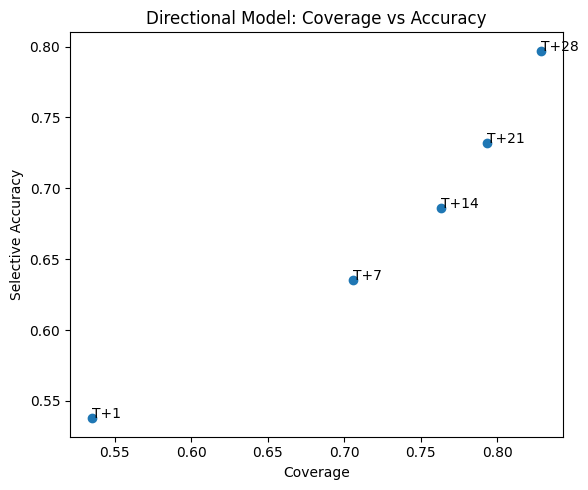

In [91]:
import matplotlib.pyplot as plt
direction_df = pd.DataFrame(direction_summary)

plt.figure(figsize=(6,5))
plt.scatter(direction_df["Coverage"], direction_df["Selective_Accuracy"])

for i, row in direction_df.iterrows():
    plt.text(row["Coverage"], row["Selective_Accuracy"], row["Horizon"])

plt.title("Directional Model: Coverage vs Accuracy")
plt.xlabel("Coverage")
plt.ylabel("Selective Accuracy")
plt.tight_layout()
plt.show()

#### 12.2 Historical Spike Tendency and T+28 Directional Signal

The top panel shows the **historical week-of-year tendency for short-term spikes**, estimated from the training data only and mapped onto the test period. The bottom panel compares the **actual 28-day occupancy change** with the model’s **T+28 directional confidence score**. Positive values indicate upward movement or upward confidence, while negative values indicate downward movement or downward confidence.

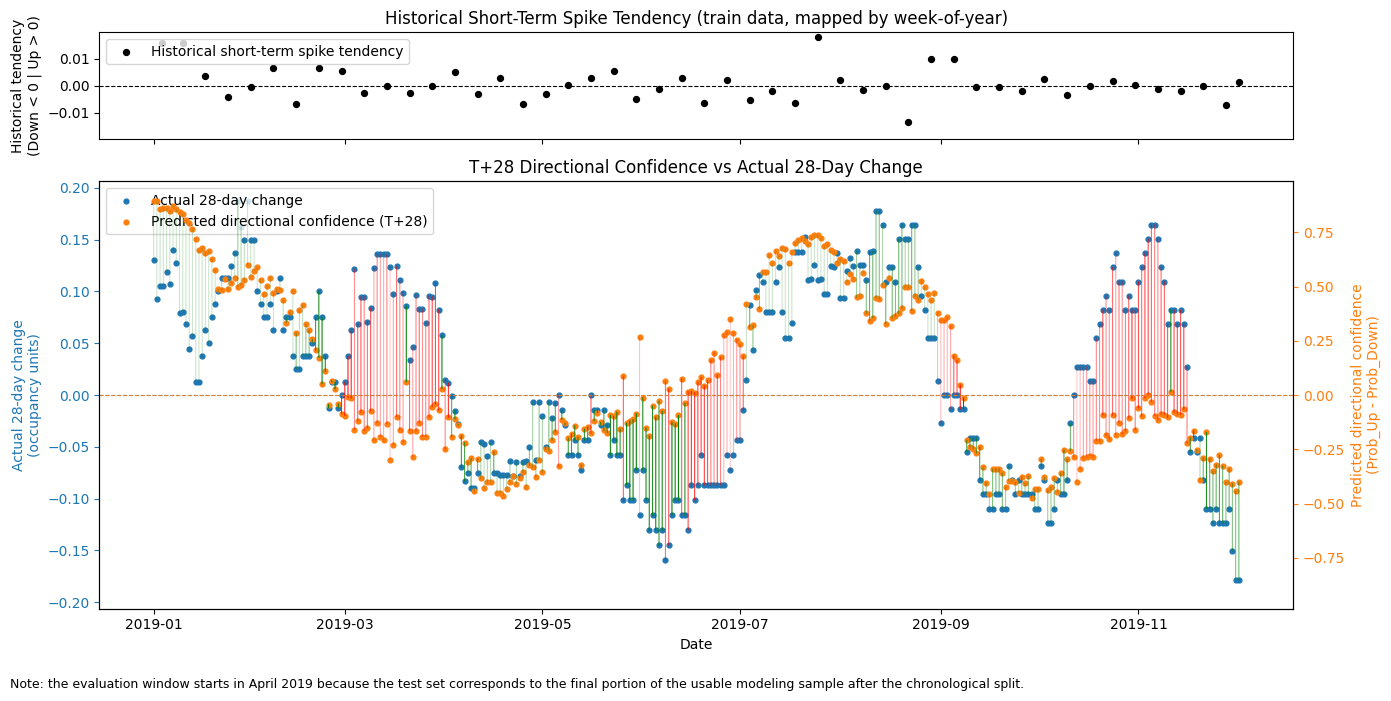

In [92]:
import matplotlib.dates as mdates
from matplotlib.patches import ConnectionPatch

# -----------------------------
# Build base dataframe for T+28
# -----------------------------
df_t28 = pd.DataFrame({
    "Date": pd.to_datetime(test["Date"].values),
    "Current": test["Occupancy"].values,
    "Actual_Future": results["T+28"]["y_test"].values,
    "Prob_Down": final_output_multi["Prob_Down_t28"].values,
    "Prob_Up": final_output_multi["Prob_Up_t28"].values
})

# -----------------------------
# Bottom panel values
# -----------------------------
df_t28["Actual_Change"] = df_t28["Actual_Future"] - df_t28["Current"]
df_t28["Predicted_Confidence"] = df_t28["Prob_Up"] - df_t28["Prob_Down"]

# Numeric dates for ConnectionPatch
df_t28["DateNum"] = mdates.date2num(df_t28["Date"])

# -----------------------------
# Historical pattern from TRAIN only
# -----------------------------
train_hist = train.copy()

train_hist["Change_t1"] = train_hist["target_t1"] - train_hist["Occupancy"]
train_hist["WeekOfYear"] = pd.to_datetime(train_hist["Date"]).dt.isocalendar().week.astype(int)

train_hist["Hist_Up"] = np.where(train_hist["Spike_Up"] == 1, train_hist["Change_t1"], 0)
train_hist["Hist_Down"] = np.where(train_hist["Spike_Down"] == 1, train_hist["Change_t1"], 0)

weekly_up = train_hist.groupby("WeekOfYear")["Hist_Up"].mean()
weekly_down = train_hist.groupby("WeekOfYear")["Hist_Down"].mean()

weekly_hist_pattern = weekly_up + weekly_down

# -----------------------------
# Map weekly pattern to test period
# -----------------------------
df_t28["WeekOfYear"] = df_t28["Date"].dt.isocalendar().week.astype(int)
df_t28["Historical_Pattern"] = df_t28["WeekOfYear"].map(weekly_hist_pattern).fillna(0)

weekly_plot = (
    df_t28.groupby("WeekOfYear", as_index=False)
    .agg(
        Historical_Pattern=("Historical_Pattern", "first"),
        Week_Start=("Date", "min"),
        Week_End=("Date", "max")
    )
)

weekly_plot["Week_Mid"] = weekly_plot["Week_Start"] + (weekly_plot["Week_End"] - weekly_plot["Week_Start"]) / 2

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(
    2, 1, figsize=(14, 7), sharex=True,
    gridspec_kw={"height_ratios": [1, 4]}
)

hist_color = "black"
actual_color = "tab:blue"
pred_color = "tab:orange"

# --- Top panel ---
axes[0].scatter(
    weekly_plot["Week_Mid"],
    weekly_plot["Historical_Pattern"],
    s=18,
    color=hist_color,
    label="Historical short-term spike tendency"
)

axes[0].axhline(0, linestyle="--", color="black", linewidth=0.8)
axes[0].set_title("Historical Short-Term Spike Tendency (train data, mapped by week-of-year)")
axes[0].set_ylabel("Historical tendency\n(Down < 0 | Up > 0)")
axes[0].legend(loc="upper left")

top_abs_max = np.nanmax(np.abs(weekly_plot["Historical_Pattern"].values))
if pd.isna(top_abs_max) or top_abs_max == 0:
    top_abs_max = 1
axes[0].set_ylim(-top_abs_max * 1.1, top_abs_max * 1.1)

# --- Bottom panel ---
ax_left = axes[1]
ax_right = ax_left.twinx()

ax_left.scatter(
    df_t28["Date"],
    df_t28["Actual_Change"],
    s=12,
    color=actual_color,
    label="Actual 28-day change"
)

ax_right.scatter(
    df_t28["Date"],
    df_t28["Predicted_Confidence"],
    s=12,
    color=pred_color,
    label="Predicted directional confidence (T+28)"
)

left_abs_max = np.nanmax(np.abs(df_t28["Actual_Change"].values))
right_abs_max = np.nanmax(np.abs(df_t28["Predicted_Confidence"].values))

if pd.isna(left_abs_max) or left_abs_max == 0:
    left_abs_max = 1
if pd.isna(right_abs_max) or right_abs_max == 0:
    right_abs_max = 1

ax_left.set_ylim(-left_abs_max * 1.1, left_abs_max * 1.1)
ax_right.set_ylim(-right_abs_max * 1.1, right_abs_max * 1.1)

ax_left.axhline(0, linestyle="--", color=actual_color, linewidth=0.8, alpha=0.8)
ax_right.axhline(0, linestyle="--", color=pred_color, linewidth=0.8, alpha=0.8)

# Links
for i in range(len(df_t28)):
    x_num = df_t28["DateNum"].iloc[i]
    y_left = df_t28["Actual_Change"].iloc[i]
    y_right = df_t28["Predicted_Confidence"].iloc[i]

    same_sign = np.sign(y_left) == np.sign(y_right)
    line_color = "green" if same_sign else "red"

    error = abs(y_left - y_right)
    alpha = max(0.2, 1 - error * 2)

    con = ConnectionPatch(
        xyA=(x_num, y_left), coordsA=ax_left.transData,
        xyB=(x_num, y_right), coordsB=ax_right.transData,
        color=line_color, alpha=alpha, linewidth=0.8
    )
    ax_right.add_artist(con)

ax_left.set_title("T+28 Directional Confidence vs Actual 28-Day Change")
ax_left.set_xlabel("Date")
ax_left.set_ylabel("Actual 28-day change\n(occupancy units)", color=actual_color)
ax_right.set_ylabel("Predicted directional confidence\n(Prob_Up - Prob_Down)", color=pred_color)

ax_left.tick_params(axis="y", colors=actual_color)
ax_right.tick_params(axis="y", colors=pred_color)

handles_left, labels_left = ax_left.get_legend_handles_labels()
handles_right, labels_right = ax_right.get_legend_handles_labels()
ax_left.legend(handles_left + handles_right, labels_left + labels_right, loc="upper left")

fig.text(
    0.01, 0.01,
    "Note: the evaluation window starts in April 2019 because the test set corresponds to the final portion of the usable modeling sample after the chronological split.",
    fontsize=9
)

# Better date formatting
ax_left.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

plt.tight_layout(rect=[0, 0.04, 1, 1])

plt.savefig("t28_directional_vs_historical_pattern.png", dpi=300, bbox_inches="tight")
plt.show()

### 13. Save outputs for downstream calibration and scoring

In [93]:
# Save a compact operational output from Notebook 2 for reference.
final_output_multi.to_csv("operational_output_nb2.csv", index=False)

# Save directional performance summary for reference.
direction_summary.to_csv("direction_summary.csv", index=False)

print("Saved:")
print("- operational_output_nb2.csv")
print("- direction_summary.csv")

pred_check = pd.DataFrame({
    "Date": test["Date"].values,
    "Occupancy": test["Occupancy"].values,
    "Actual_t1": results["T+1"]["y_test"].values,
    "Pred_t1": results["T+1"]["pred"],
    "Actual_t7": results["T+7"]["y_test"].values,
    "Pred_t7": results["T+7"]["pred"],
    "Actual_t14": results["T+14"]["y_test"].values,
    "Pred_t14": results["T+14"]["pred"],
    "Actual_t21": results["T+21"]["y_test"].values,
    "Pred_t21": results["T+21"]["pred"],
    "Actual_t28": results["T+28"]["y_test"].values,
    "Pred_t28": results["T+28"]["pred"],
})

pred_check.to_csv("pred_check_nb2.csv", index=False)

print("Saved:")
print("- operational_output_nb2.csv")
print("- direction_summary.csv")
print("- pred_check_nb2.csv")

Saved:
- operational_output_nb2.csv
- direction_summary.csv
Saved:
- operational_output_nb2.csv
- direction_summary.csv
- pred_check_nb2.csv
